In [1]:
import sys
import os

sys.path.insert(0, os.path.abspath('C:/Users/dagic/OneDrive/Documents/KAIM/Week_2/fintech-review-analytics'))

print('Path set. Python will now look in:', os.path.abspath('C:/Users/dagic/OneDrive/Documents/KAIM/Week_2/fintech-review-analytics'))

Path set. Python will now look in: C:\Users\dagic\OneDrive\Documents\KAIM\Week_2\fintech-review-analytics


In [2]:
# Core libraries
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import word_tokenize, pos_tag
from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from collections import Counter
from wordcloud import WordCloud
from datetime import datetime
from google_play_scraper import app, reviews, Sort

# Download necessary NLTK components
for res in ['vader_lexicon', 'stopwords', 'averaged_perceptron_tagger', 'punkt', 'wordnet']:
    nltk.download(res, quiet=True)

sia = SentimentIntensityAnalyzer()
stop_words = set(stopwords.words('english'))

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)
print("Environment ready ✓")

from src.data_scrapper import scrape_metadata, scrape_reviews, data_quality_check
from src.data_preprocessor import missing_values, duplicate_reviews, check_dateFormat, missing_values, normalize_date, clean_text, invalid_reviews, remove_duplicates, save_cleaned_data, preprocessing_report
from src.modular_nlp_pipeline import modular_nlp_pipeline, get_top_ngrams

print("Libraries loaded successfully!")

Environment ready ✓
Libraries loaded successfully!


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\dagic\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\dagic\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\dagic\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## Combine the cleaned datasets of CBE, BOA and Dashen

In [ ]:
# Load cleaned datasets
dashen = pd.read_csv("../data/processed/cleaned_dashen_reviews.csv")
boa   = pd.read_csv("../data/processed/cleaned_boa_reviews.csv")
cbe   = pd.read_csv("../data/processed/cleaned_cbe_reviews.csv")

# Combine them
df_all = pd.concat([dashen, boa, cbe], ignore_index=True)

print(df_all.shape)
df_all.head()

(1500, 7)


,Unnamed: 0,review_id,review,rating,date,bank,source
0,0,12ebd51a-7912-464b-a81b-14a0aac358da,ok,5,2026-05-15,Dashen Bank,Google Play
1,1,68dd84a3-07ab-41d9-aff8-ad7916ff71a8,best app so far. thank you,5,2026-05-15,Dashen Bank,Google Play
2,2,78284116-8313-4ca8-a28c-61ce4fa44ee6,Very Annoying App i tried to open virtual bank...,1,2026-05-14,Dashen Bank,Google Play
3,3,b4a7ea95-727b-4501-8d84-77db88187c84,good,5,2026-05-14,Dashen Bank,Google Play
4,4,59a20f9e-bb87-4d5f-bee7-ce19f19baddf,good,5,2026-05-14,Dashen Bank,Google Play


## Tokenization and Lemmatization

In [4]:
# Apply cleaning
print("Running modular preprocessing...")
df_all['clean_text'] = df_all['review'].apply(modular_nlp_pipeline)

# Drop invalid/too short reviews
df_clean = df_all[df_all['clean_text'].str.len() > 2].copy()
print(f"Final cleaned dataset size: {len(df_clean)}")

Running modular preprocessing...
Final cleaned dataset size: 1390


### Rating & Data Quality Distribution

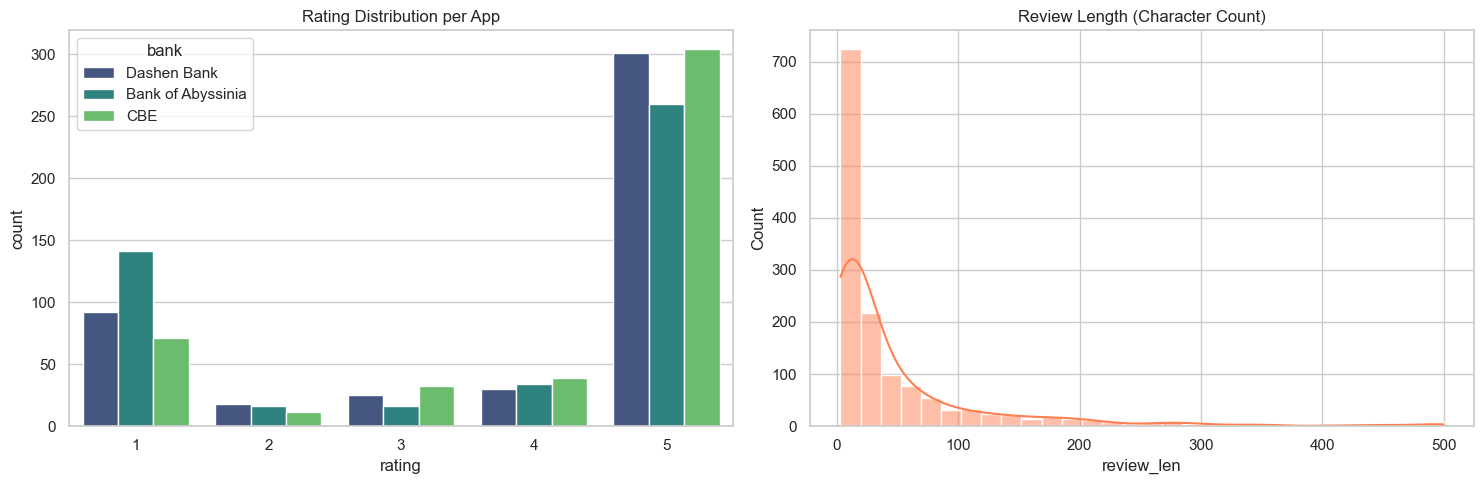

In [5]:
# Visualizing Distributions
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Rating per App
sns.countplot(data=df_clean, x='rating', hue='bank', palette='viridis', ax=ax[0])
ax[0].set_title('Rating Distribution per App')

# Review Length
df_clean['review_len'] = df_clean['review'].str.len()
sns.histplot(df_clean['review_len'], bins=30, kde=True, ax=ax[1], color='coral')
ax[1].set_title('Review Length (Character Count)')

plt.tight_layout(); plt.show()

#### Interpretation
    - BOA is having a nticable customer dissatisfaction with higher 1 star, having a lower 5 star than others.
    - CBE relatively have reached at a peak satisfaction. 

As shown above on Review length, most of the reviews are short phrases like 'nice app', 'great app' or 'not working'.
Hence, in order to understand the sentiment of those short lengthed reviews, VADER has been chosen.

### Keyword Extraction


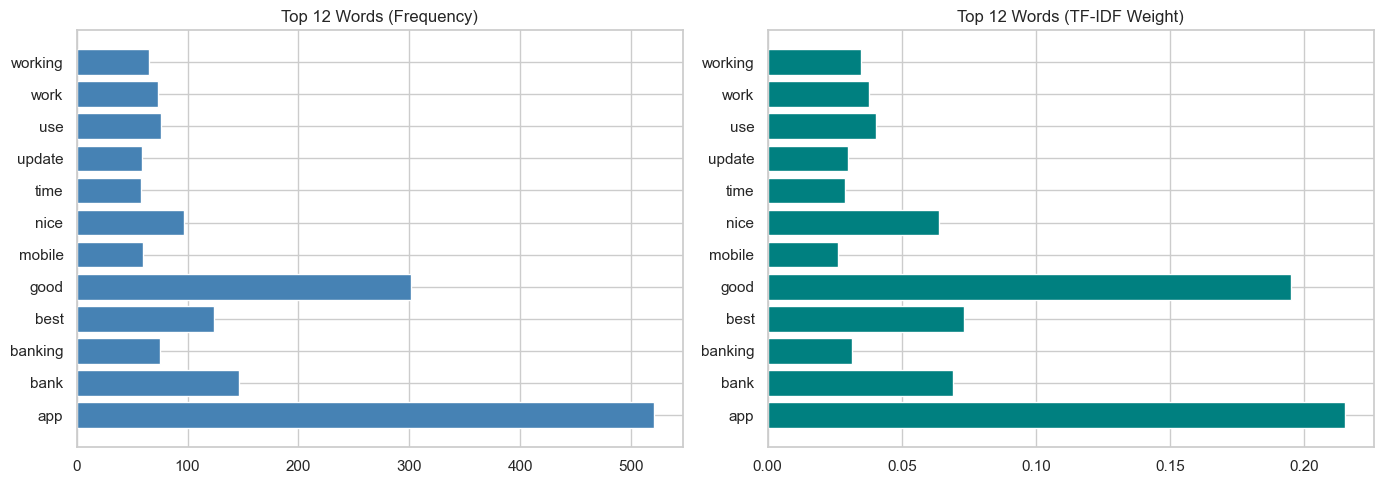

In [6]:
# Frequency (BoW) vs TF-IDF
tfidf_vec = TfidfVectorizer(max_features=12, stop_words='english')
X_tfidf = tfidf_vec.fit_transform(df_clean['clean_text'])

cv_vec = CountVectorizer(max_features=12, stop_words='english')
X_cv = cv_vec.fit_transform(df_clean['clean_text'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(cv_vec.get_feature_names_out(), X_cv.toarray().sum(axis=0), color='steelblue')
axes[0].set_title('Top 12 Words (Frequency)')

axes[1].barh(tfidf_vec.get_feature_names_out(), X_tfidf.toarray().mean(axis=0), color='teal')
axes[1].set_title('Top 12 Words (TF-IDF Weight)')

plt.tight_layout(); plt.show()

#### Interpretation
    - The most frequent words that appear on most reviews indicates that the good functionality of the application.

## N-gram Analysis

### Note:
Here I was trying to modularize the N-gram function, however I kept getting this error no matter what I change.

C:\Users\dagic\AppData\Local\Temp\ipykernel_27448\40103568.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bi, x='count', y='ngram', ax=axes[0], palette='Greens_r')
C:\Users\dagic\AppData\Local\Temp\ipykernel_27448\40103568.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tri, x='count', y='ngram', ax=axes[1], palette='Purples_r')


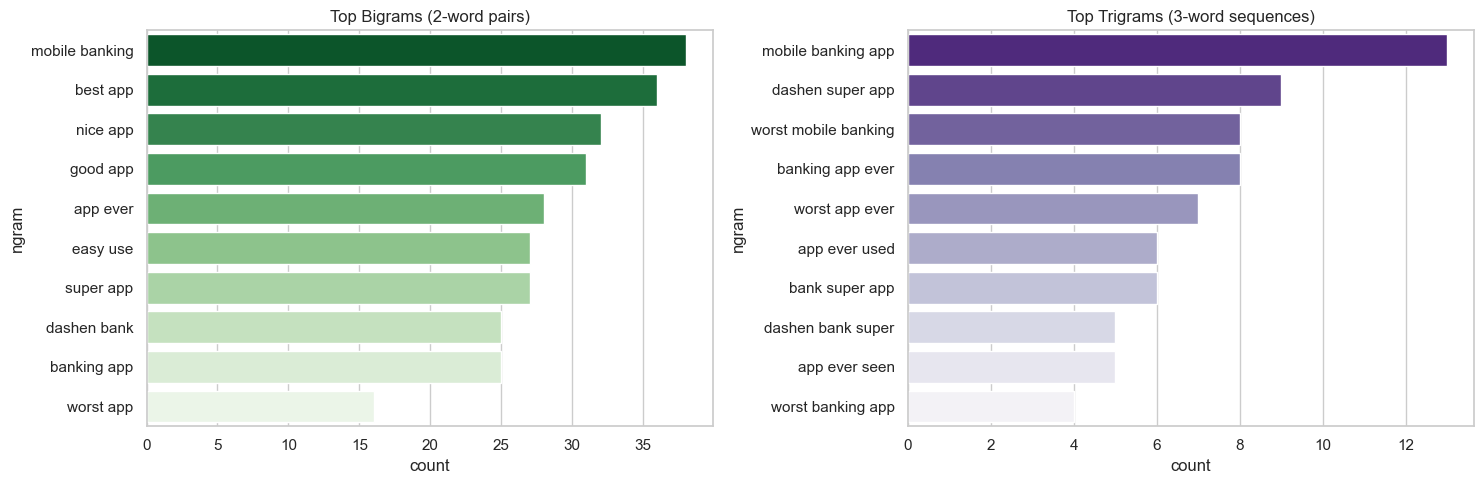

In [8]:
def get_top_ngrams(corpus, n, k=10):
    vec = CountVectorizer(ngram_range=(n,n), max_features=100)
    X = vec.fit_transform(corpus)
    counts = X.sum(axis=0).A1
    return pd.DataFrame({'ngram': vec.get_feature_names_out(), 'count': counts}).sort_values('count', ascending=False).head(k)

bi = get_top_ngrams(df_clean['clean_text'], 2)
tri = get_top_ngrams(df_clean['clean_text'], 3)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=bi, x='count', y='ngram', ax=axes[0], palette='Greens_r')
axes[0].set_title('Top Bigrams (2-word pairs)')
sns.barplot(data=tri, x='count', y='ngram', ax=axes[1], palette='Purples_r')
axes[1].set_title('Top Trigrams (3-word sequences)')
plt.tight_layout(); plt.show()

#### Interpretation
    - In the Top Bigrams graph, it depicts that a positive two worded reviews are more redundant.
    - On the contrary in the Top Trigrams plot, it depicts that a negative three worded reviews are more redundant.

## POS Tagging & Noun Extraction

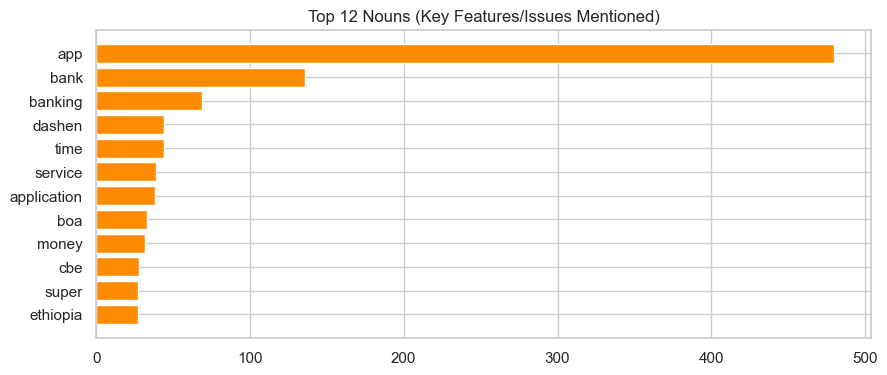

In [9]:
# Download the specific tagger if it's not already downloaded
try:
    nltk.data.find('taggers/averaged_perceptron_tagger_eng')
except LookupError:
    nltk.download('averaged_perceptron_tagger_eng', quiet=True)

def extract_nouns(text):
    tokens = word_tokenize(text)
    return [w.lower() for w, p in pos_tag(tokens) if p.startswith('NN') and len(w) > 2 and w.lower() not in stop_words]

df_clean['nouns'] = df_clean['review'].apply(extract_nouns)
all_nouns = [n for ns in df_clean['nouns'] for n in ns]
noun_counts = Counter(all_nouns).most_common(12)

plt.figure(figsize=(10, 4))
plt.barh([x[0] for x in noun_counts][::-1], [x[1] for x in noun_counts][::-1], color='darkorange')
plt.title('Top 12 Nouns (Key Features/Issues Mentioned)')
plt.show()

## Word Cloud

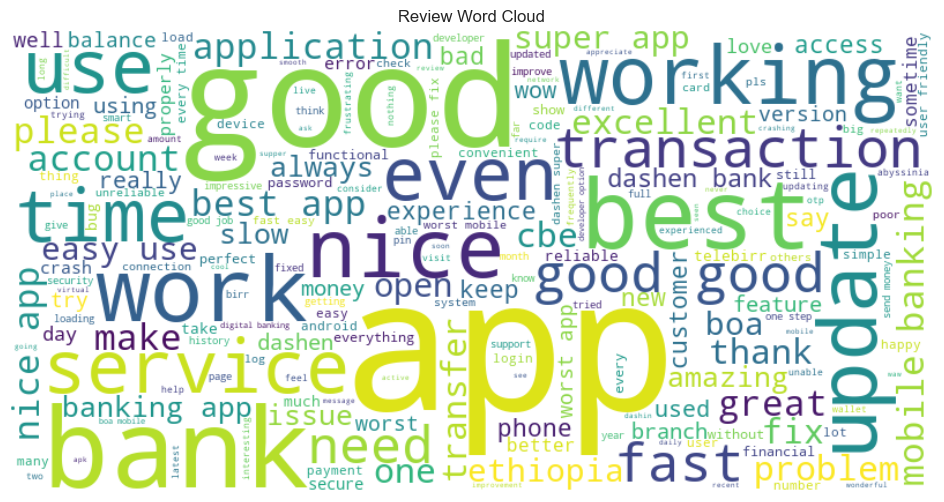

In [10]:
text_combined = " ".join(df_clean['clean_text'])
wc = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(text_combined)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Review Word Cloud')
plt.show()

## Multi-Model Sentiment Analysis

### Lexicon Comparison

In [12]:
# Sentiment Application
df_clean['vader_compound'] = df_clean['review'].apply(lambda x: sia.polarity_scores(x)['compound'])
df_clean['tb_polarity'] = df_clean['review'].apply(lambda x: TextBlob(x).sentiment.polarity)
df_clean['tb_subjectivity'] = df_clean['review'].apply(lambda x: TextBlob(x).sentiment.subjectivity)

def get_label(s):
    return 'positive' if s >= 0.05 else ('negative' if s <= -0.05 else 'neutral')

df_clean['sentiment'] = df_clean['vader_compound'].apply(get_label)
print("VADER Distribution:\n", df_clean['sentiment'].value_counts(normalize=True).round(2))

VADER Distribution:
 sentiment
positive    0.63
neutral     0.22
negative    0.15
Name: proportion, dtype: float64


#### Interpretation
    The Vader distrubition showed that:
        - 65% of the total review are positive
        - 22% is neutral
        - 15% is negative
    ** this 15% of negative reviews should be analysed carefully, as it might be a bottleneck for the operational service delivery for the fintech companies.

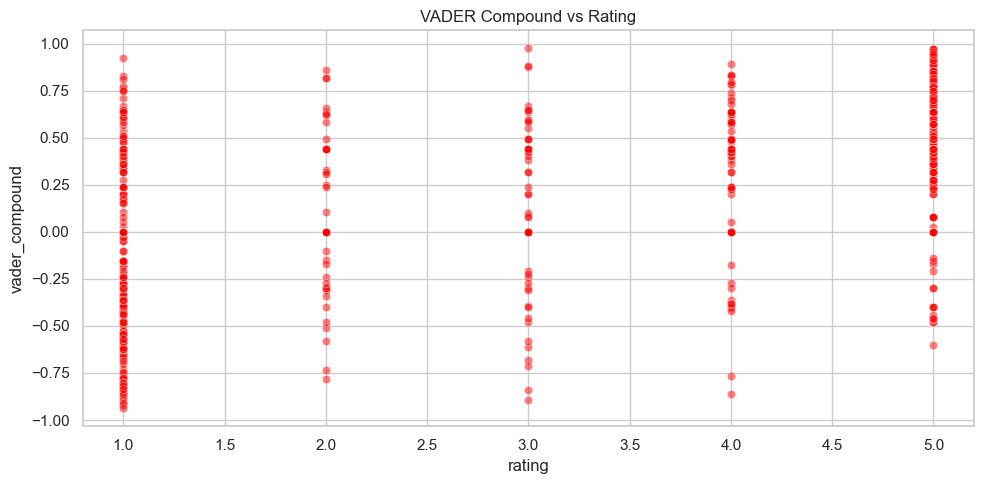

In [24]:
# Sentiment vs. Star Rating
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

# VADER Scatter
sns.scatterplot(data=df_clean, x='rating', y='vader_compound', alpha=0.5, color='red')
ax.set_title('VADER Compound vs Rating')

plt.tight_layout(); plt.show()

#### Interpretation:
    - the rate 1 is highly populated which shows that the reviews are intentionally and semantically negative.
    - also the 5 rate is also dense with a strong positive reviews.


### Transformer-based Sentiment

In [28]:
# Transformer Pipeline
try:
    from transformers import pipeline
    sent_model = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english", truncation = True)

    # Apply transformer to all reviews in df_clean
    transformer_results = []
    # Process in batches to handle memory and speed, if df_clean is very large
    batch_size = 16 # Adjust batch size as needed
    for i in range(0, len(df_clean), batch_size): # Changed desc here
        batch = df_clean['review'].iloc[i:i + batch_size].tolist()
        preds = sent_model(batch)
        transformer_results.extend(preds)

    # Parsing results
    df_clean['transformer_sentiment_label'] = [p['label'] for p in transformer_results]
    df_clean['transformer_sentiment_score'] = [p['score'] if p['label'] == 'POSITIVE' else -p['score'] for p in transformer_results]

    # displaying the resut
    print("\nTransformer Sentiment Distribution:")
    print(df_clean['transformer_sentiment_label'].value_counts(normalize=True).round(2))

except Exception as e:
    print(f"Transformer skipped: {e}")

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 2991.82it/s]



Transformer Sentiment Distribution:
transformer_sentiment_label
POSITIVE    0.64
NEGATIVE    0.36
Name: proportion, dtype: float64


#### Interpretation:
    * The DistilBERT transformer sentiment analyser depicts that 64 % of reviews are positive and 36% is negative. This analysis does not reveal the neutral reviews.

### Sentiment Model Comparison: VADER and Transformer

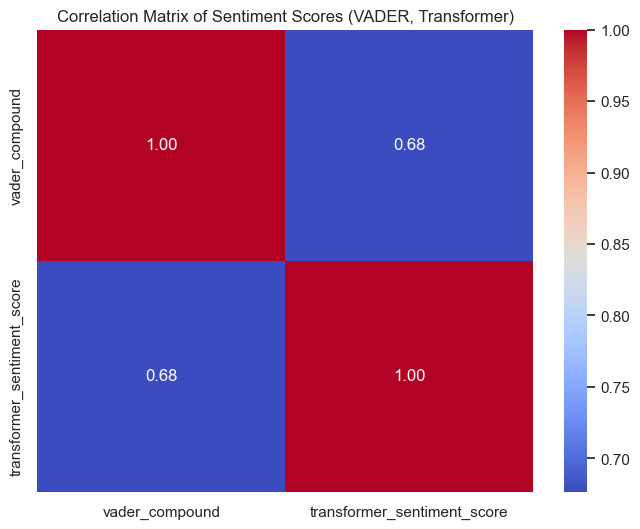

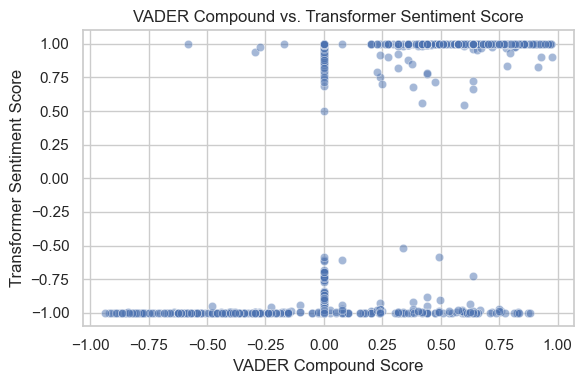

In [39]:
# Visualizing Sentiment Score Correlation

# Ensure transformer_sentiment_score is available
if 'transformer_sentiment_score' not in df_clean.columns:
    print("Transformer sentiment scores not available for comparison.")
else:
    # Create a DataFrame for correlation
    sentiment_scores = df_clean[['vader_compound', 'transformer_sentiment_score']]

    # Calculate the correlation matrix
    correlation_matrix = sentiment_scores.corr()

    plt.figure(figsize=(8, 6))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Correlation Matrix of Sentiment Scores (VADER, Transformer)')
    plt.show()

    # Plotting scatter plots for pairwise comparison
    fig, ax = plt.subplots(1, 1, figsize=(6, 4))

    sns.scatterplot(data=df_clean, x='vader_compound', y='transformer_sentiment_score', alpha=0.5)
    ax.set_title('VADER Compound vs. Transformer Sentiment Score')
    ax.set_xlabel('VADER Compound Score')
    ax.set_ylabel('Transformer Sentiment Score')


    plt.tight_layout()
    plt.show()

#### Interpretation

    * Correlation 
        -   Both the Vader and transformer agrees on 68% of positive reviews, however there is disagreement between those about the rest 32% of the reviews.

    * Scatterplot
        - There is a up rising plot at 0.00, this is where thee vader marked neutral reviews where transformer doesnot have neutral category, it adds those to either the positive or neutral reviews.

          


### # Comparing Sentiment Distributions

In [40]:
if 'transformer_sentiment_label' not in df_clean.columns:
    print("Transformer sentiment labels not available for comparison.")
else:
    print("\n--- Sentiment Label Distributions ---")
    print("VADER Distribution:\n", df_clean['sentiment'].value_counts(normalize=True).round(2))
    print("\nTextBlob Polarity Distribution (thresholded at +/-0.05):\n")
    def get_tb_label(s):
        return 'positive' if s >= 0.05 else ('negative' if s <= -0.05 else 'neutral')
    print(df_clean['tb_polarity'].apply(get_tb_label).value_counts(normalize=True).round(2))
    print("\nTransformer Distribution:\n", df_clean['transformer_sentiment_label'].value_counts(normalize=True).round(2))


--- Sentiment Label Distributions ---
VADER Distribution:
 sentiment
positive    0.63
neutral     0.22
negative    0.15
Name: proportion, dtype: float64

TextBlob Polarity Distribution (thresholded at +/-0.05):

tb_polarity
positive    0.64
neutral     0.25
negative    0.11
Name: proportion, dtype: float64

Transformer Distribution:
 transformer_sentiment_label
POSITIVE    0.64
NEGATIVE    0.36
Name: proportion, dtype: float64


#### Interpretation
both textblob and transformer graded positive reviews to 68%

## Aggregating Sentiment Scores by App and Star Rating

rating,1,2,3,4,5
bank,,,,,
Bank of Abyssinia,-0.179728,0.055212,0.130938,0.328109,0.374035
CBE,-0.030277,0.240627,-0.052356,0.233833,0.409565
Dashen Bank,-0.155179,0.036511,0.294912,0.389890,0.457104


rating,1,2,3,4,5
bank,,,,,
Bank of Abyssinia,-0.105977,0.112909,0.243804,0.422623,0.500680
CBE,0.012485,0.254683,0.181723,0.343767,0.530704
Dashen Bank,-0.175189,0.162729,0.199669,0.445383,0.485419


rating,1,2,3,4,5
bank,,,,,
Bank of Abyssinia,-0.827314,-0.563670,-0.258675,0.121218,0.698597
CBE,-0.571821,-0.654702,-0.367995,0.086744,0.780010
Dashen Bank,-0.766496,-0.556521,-0.509572,0.455182,0.787976


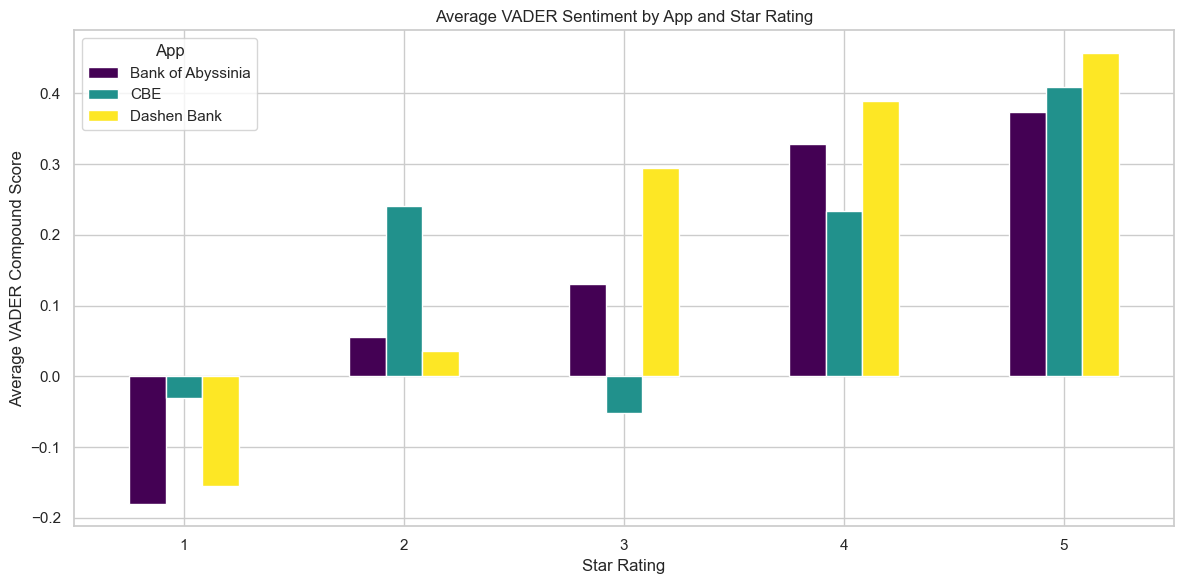

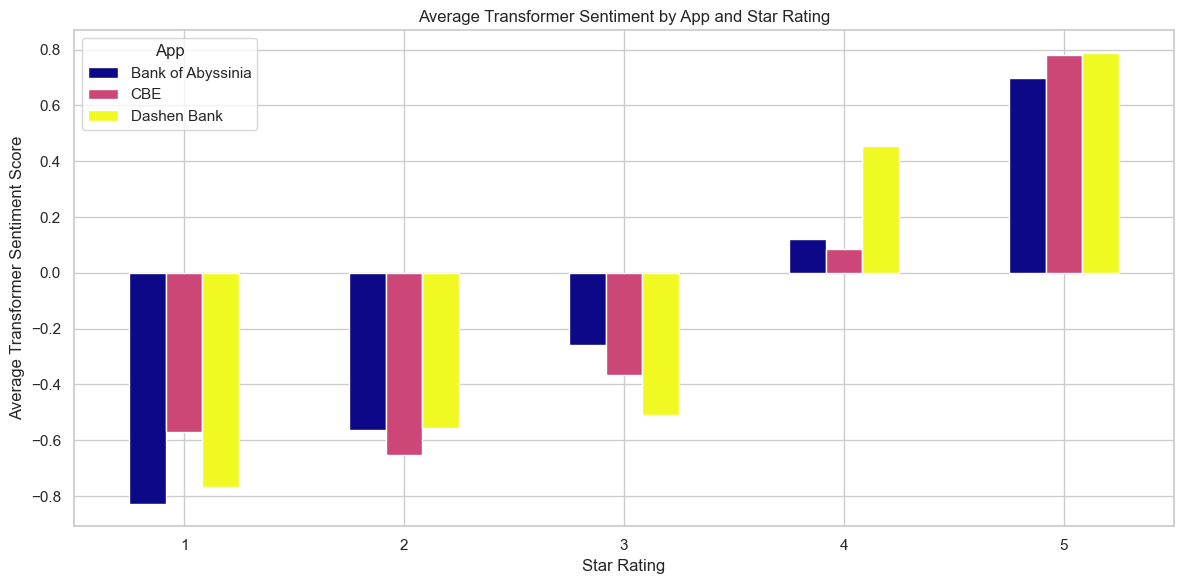

In [35]:
# Aggregate VADER sentiment scores by bank and star rating
vader_agg_sentiment = df_clean.groupby(['bank', 'rating'])['vader_compound'].mean().unstack()
display(vader_agg_sentiment)

# Aggregate TextBlob polarity scores by bank and star rating
tb_agg_sentiment = df_clean.groupby(['bank', 'rating'])['tb_polarity'].mean().unstack()
display(tb_agg_sentiment)

# Aggregate Transformer sentiment scores by bank and star rating
transformer_agg_sentiment = df_clean.groupby(['bank', 'rating'])['transformer_sentiment_score'].mean().unstack()
display(transformer_agg_sentiment)

# Visualize VADER sentiment by bank and rating
vader_agg_sentiment.T.plot(kind='bar', figsize=(12, 6), colormap='viridis')
plt.title('Average VADER Sentiment by App and Star Rating')
plt.xlabel('Star Rating')
plt.ylabel('Average VADER Compound Score')
plt.xticks(rotation=0)
plt.legend(title='App')
plt.tight_layout()
plt.show()

# Visualize Transformer sentiment by bank and rating
transformer_agg_sentiment.T.plot(kind='bar', figsize=(12, 6), colormap='plasma')
plt.title('Average Transformer Sentiment by App and Star Rating')
plt.xlabel('Star Rating')
plt.ylabel('Average Transformer Sentiment Score')
plt.xticks(rotation=0)
plt.legend(title='App')
plt.tight_layout()
plt.show()

#### Interpretation

    * Average VADER Sentiment by App and Star Rating
        - 1 star rating is considered as negative review.
        - rating 2 and 3 for CBE and Dashen respectively, are given a high score, where in real word rating 2 is a sign of dissatisfaction.
        - likewise rating 3 is given low score for CBE or considered as negative, however in real life rating 3 does not neccessarly mean its negative review.


    * Average Transformer Sentiment by App and Star Rating
        - the rating 1, 2 and 3 are considered as negative
        - 4 and 5 are seen as positive.
         

### Thematic Analysis

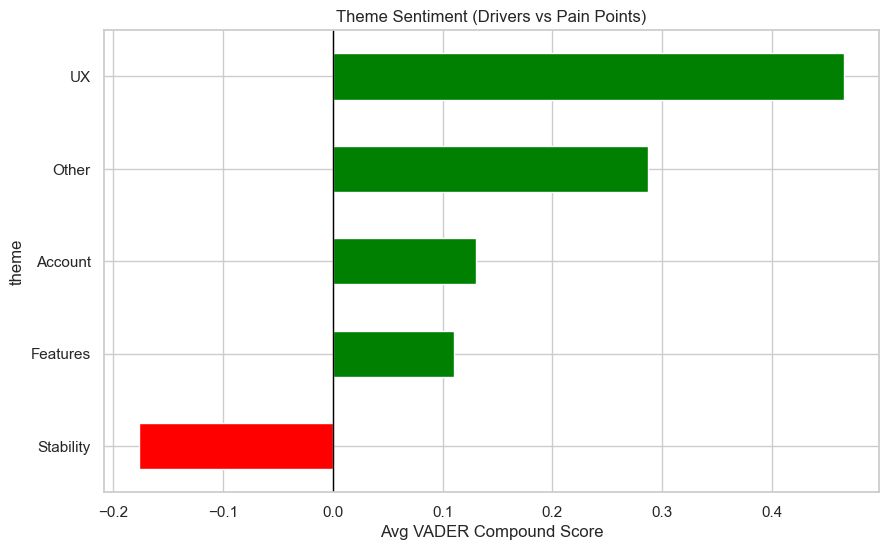

In [36]:
# Business Theme Mapping
THEME_MAP = {
    'Stability': ['crash', 'freeze', 'bug', 'error', 'slow', 'stuck', 'failed'],
    'Account': ['login', 'otp', 'password', 'account', 'verify', 'sign'],
    'UX': ['ui', 'interface', 'clean', 'easy', 'navigation', 'design'],
    'Features': ['transfer', 'payment', 'bill', 'card', 'wallet', 'money']
}

def get_theme(txt):
    txt = txt.lower()
    for theme, keywords in THEME_MAP.items():
        if any(w in txt for w in keywords): return theme
    return 'Other'

df_clean['theme'] = df_clean['review'].apply(get_theme)
theme_sent = df_clean.groupby('theme')['vader_compound'].mean().sort_values()

plt.figure(figsize=(10, 6))
colors = ['red' if x < 0 else 'green' for x in theme_sent.values]
theme_sent.plot(kind='barh', color=colors)
plt.title('Theme Sentiment (Drivers vs Pain Points)')
plt.xlabel('Avg VADER Compound Score')
plt.axvline(0, color='black', lw=1)
plt.show()

#### Interpretation


    - Most of the positive reviews are on UX of the applications. However the stability of the apps is in question which leads to a conclusion to app crashes, freezes or fail to open during tranction or something. This is a catastropic issue for the Fintech companies.

### Thematic Analysis per Bank

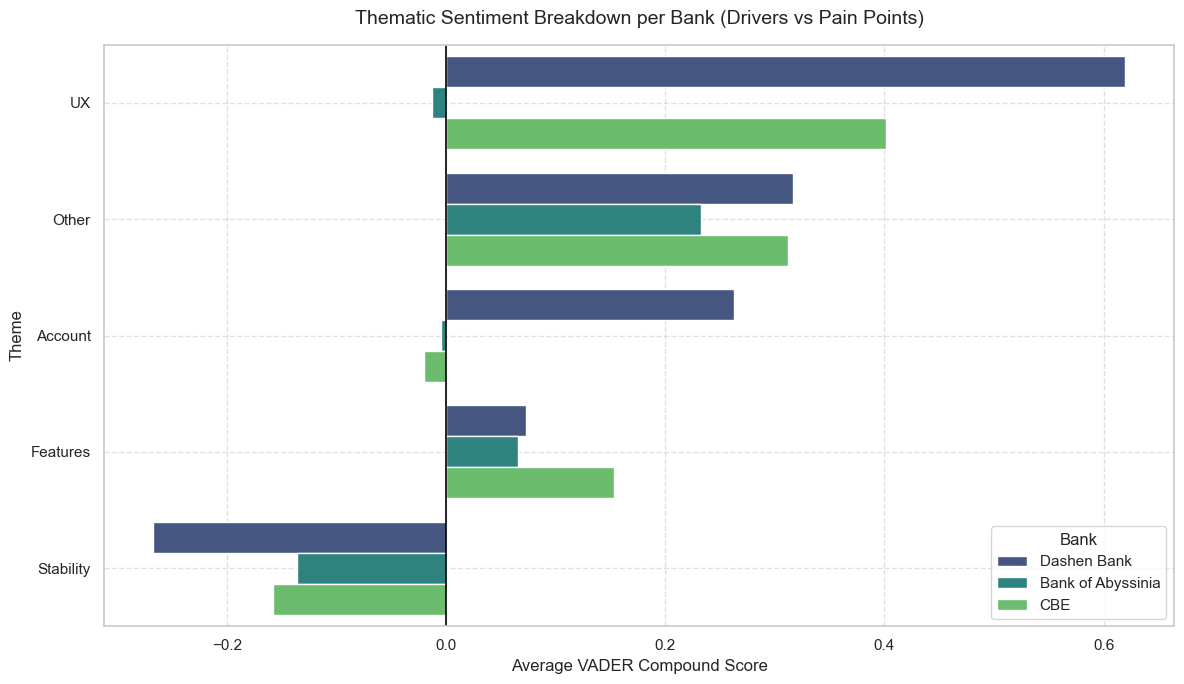

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the sorted order of themes based on overall average sentiment
# This ensures the bars are organized from highest driver to lowest pain point
theme_order = (
    df_clean.groupby('theme')['vader_compound']
    .mean()
    .sort_values(ascending=False)
    .index
)

# 2. Initialize the plot using subplots (avoids plt.figure)
fig, ax = plt.subplots(figsize=(12, 7))

# 3. Create the grouped horizontal bar chart
sns.barplot(
    data=df_clean,
    x='vader_compound',
    y='theme',
    hue='bank',          # This splits each theme into 3 distinct bars per bank
    order=theme_order,   # Keeps the themes beautifully sorted
    errorbar=None,       # Removes confidence intervals for a cleaner look
    palette='viridis',   # Reuses a clean palette matching your framework style
    ax=ax
)

# 4. Strategic formatting adjustments
# Add a solid vertical line at 0.0 to clearly isolate the positive vs. negative zones
ax.axvline(0, color='black', linestyle='-', linewidth=1.2)

# Set clean, professional titles and labels
ax.set_title('Thematic Sentiment Breakdown per Bank (Drivers vs Pain Points)', fontsize=14, pad=15)
ax.set_xlabel('Average VADER Compound Score', fontsize=12)
ax.set_ylabel('Theme', fontsize=12)

# Clean up grid lines and legend positioning
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(title='Bank', loc='lower right', frameon=True)

# 5. Save the report-ready visualization
plt.tight_layout()
plt.savefig('theme_sentiment_per_bank.png', dpi=300)

#### Interpretation


    UX:
        -   Dashen has an excellent UX thsn others, 
        -   BOA has the worst experiance on UX

    Account:
        -   Dashen has a good review on account access experiance
        -   CBE has the worst review regarding acoount access
        -   BOA also has worst review 

    Feature:
        -   CBE has a relatively good experiance on money flow experience
        -   both Dashen and BOA has a good reputation on this features

    Other:
        -  on any other features other than the specified themes, all three has a good review.

In [43]:
df_clean.head(1)

,Unnamed: 0,review_id,review,rating,date,bank,source,clean_text,review_len,nouns,vader_compound,tb_polarity,tb_subjectivity,sentiment,transformer_sentiment_label,transformer_sentiment_score,theme
1,1,68dd84a3-07ab-41d9-aff8-ad7916ff71a8,best app so far. thank you,5,2026-05-15,Dashen Bank,Google Play,best app far thank,26,[app],0.7893,0.55,0.65,positive,POSITIVE,0.999848,Other


### Export Results

In [44]:
# Cell 6: Saving Results
output_cols = ['review_id', 'bank', 'review', 'rating', 'date', 'sentiment', 'transformer_sentiment_score', 'theme', 'source']
df_final = df_clean[output_cols]

# Save to CSV
df_final.to_csv('fintech_sentiment_analysis_results.csv', index=False)
print("✓ Pipeline results saved as 'fintech_sentiment_analysis_results.csv'")
df_final.head()

✓ Pipeline results saved as 'fintech_sentiment_analysis_results.csv'


,review_id,bank,review,rating,date,sentiment,transformer_sentiment_score,theme,source
1,68dd84a3-07ab-41d9-aff8-ad7916ff71a8,Dashen Bank,best app so far. thank you,5,2026-05-15,positive,0.999848,Other,Google Play
2,78284116-8313-4ca8-a28c-61ce4fa44ee6,Dashen Bank,Very Annoying App i tried to open virtual bank...,1,2026-05-14,negative,-0.999444,Account,Google Play
3,b4a7ea95-727b-4501-8d84-77db88187c84,Dashen Bank,good,5,2026-05-14,positive,0.999816,Other,Google Play
4,59a20f9e-bb87-4d5f-bee7-ce19f19baddf,Dashen Bank,good,5,2026-05-14,positive,0.999816,Other,Google Play
5,fc184115-ab13-482b-bb08-798589a4d482,Dashen Bank,good app but it was doesnt work other bank tra...,5,2026-05-14,positive,-0.996920,UX,Google Play


## Bank Code used:

Bank                                Code

Dashen Bank                         Dashen bank

Commercial Bank of Ethiopia         CBE

Boank of Abyssinia                  Boank of Abyssinia
